# Evaluación de la robustez de explicaciones en LLMs mediante perturbaciones narrativas

## Autora

Isabel Tejedor Burón

--------------------

# Resumen

Este proyecto presenta un estudio experimental de Inteligencia Artificial Explicable (XAI) aplicado a modelos de lenguaje grandes (LLMs), analizando la robustez de sus explicaciones mediante perturbaciones controladas del input narrativo.

A diferencia de XAI tradicional, este proyecto no evalúa un modelo predictivo, sino que estudia al LLM como generador de explicaciones sobre historias narrativas, lo que convierte así, a la explicación como el punto principal de análisis.

Para realizar este proyecto se ha construido un pipeline experimental que incluye adquisición de datos, análisis exploratorio, representación semántica mediante embeddings, generación de explicaciones con LLaMA 3 8B y evaluación mediante perturbaciones controladas.

Por último, se mide la estabilidad de las explicaciones mediante el Perturbation Sensitivity Score (PSS), basado en la similitud del coseno entre embeddings de las explicaciones. Los resultados muestran una alta estabilidad frente a perturbaciones lingüísticas, pero una sensibilidad a cambios temporales y estructurales.

# 1. Introducción

La XAI clásica tiene como objetivo explicar las decisiones de los modelos predictivos mediante la atribución de importancia a las variables de salida. Sin embargo, en la IA generativa, las explicaciones en lenguaje natural no necesariamente muestran los procesos causales internos, sino que pueden ser racionalizaciones plausibles del input.

En este proyecto, en lugar de explicar predicciones, se analiza la robustez de las explicaciones generadas por un LLM bajo perturbaciones controladas del input narrativo. El objetivo es estudiar la consistencia de las explicaciones como objeto en si mismo.

Este proyecto se apoya en los conceptos de la asignatura de Técnicas de IA Explicable, especialmente en la estabilidad de explicaciones bajo perturbaciones y su relación con la fidelidad. En este caso, la fidelidad se define respecto a la consistencia del contenido explicativo generado por el LLM.

# 2. Datos

Se utiliza el dataset _1000 stories - 100 genres (Kaggle)_. Las historias se descargan y se almacenan en data/raw para garantizar reproducibilidad.

El dataset contiene aproximadamente 99 géneros con distribución equilibrada, lo que permite alta diversidad narrativa.

Se realiza un muestreo de 3 historias por género (297 en total). Debido a restricciones computacionales, los experimentos finales se realizan sobre 10 historias representativas.

# 3. Modelos

Se utiliza LLaMA 3 8B como sistema de generación de explicaciones _(LLM-as-explainer)_. Cada historia se transforma en una estructura JSON. \1
```
{
  "characters": "...", # **En términos de XAI, este componente permite evaluar la fidelidad a nivel de entidades.**
  "events": "...", # **En términos de XAI, este componente permite estudiar la selección de información en el proceso de explicación**
  "causal_relations": "...", # **En XAI, esta relacionado con: perturbation-based analysis, counterfactual reasoning, rationalization problem; permite evaluar el grado de comprensión causal del modelo.**
  "narrative_structure": "..." # **En XAI permite evaluar coherencia global de la explicación, estabilidad del razonamiento ante variaciones del input, consistencia entre múltiples generaciones**
}
```

El modelo se controla mediante prompting estructurado (system + user prompt), lo que restringe inferencias no presentes en el texto y fuerza salida en JSON.

El modelo se ejecuta con temperatura 0 para garantizar una estabilidad entre generaciones.

Para la representación semántica se utiliza SentenceTransformers (all-MiniLM-L6-v2), generando embeddings de historias y explicaciones.

# 4. Explicaciones 

## 4.1. Pipeline completo

Este proyecto sigue un pipeline reproducible en seis etapas. \1
1. Etapa 1: carga de datos

Se utiliza el dataset _1000 stories - 100 genres (Kaggle)_. Las historias se descargan y se almacenan en data/raw para garantizar reproducibilidad.

2. Etapa 2: análisis exploratorio (EDA)

Se analiza la estructura del dataset, la distribución de géneros, la longitud de textos y la presencia de patrones narrativos.

3. Etapa 3: muestreo estratificado

Se construye un subconjunto balanceado de 3 historias por género (297 en total). Debido a restricciones computacionales, los experimentos se realizan sobre 10 historias representativas.

4. Etapa 4: representación semántica

Se generan embeddings con SentenceTransformers (all-MiniLM-L6-v2) para representar historias en un espacio vectorial. 

Tras ello, se aplica clustering no supervisado con el objetivo de analizar si existen agrupaciones naturales en el espacio semántico, sin utilizar etiquetas de género. Los resultados indican que no existe una estructura clara en el espacio de embeddings, lo que motiva el uso de perturbaciones como herramienta principal de análisis.

5. Etapa 5: generación de explicaciones con LLM

Se utiliza LLaMA 3 8B como sistema de generación de explicaciones _(LLM-as-explainer)_. Cada historia se transforma en una estructura JSON.

6. Etapa 6: perturbation-based XAI (evaluación principal)

Se construye un conjunto de perturbaciones controladas. \1
- Perturbaciones estructurales. \1    - Eliminación de oraciones finales
    - Shuffle de oraciones
    - Reverse order 
- Perturbaciones semánticas. \1    - Eliminación de eventos
    - Inversión contrafactual
    - Repetición de eventos
- Perturbaciones de entidades. \1    - Colapso de personajes a ENTITY
    - Reasignación de roles
- Perturbaciones lingüísticas. \1    - Paraphrasing
    - Inverse paraphrasing
- Ruido. \1    - Inyección de frases irrelevantes

## 4.2. Funciones de perturbación

Cada perturbación modifica un aspecto específico del input narrativo y permite analizar diferentes dimensiones de robustez en el marco de XAI basado en perturbaciones (inspirado en LIME).

1. Eliminación de información
    - Elimina las últimas frases de la historia.
    - Simula la pérdida de información causal en el desenlace.
    - Evalúa si la explicación depende del final de la narrativa.
    - PSS alto: el modelo no depende del final de la historia.

2. Permutación de estructura narrativa
    - Desordena aleatoriamente las frases de la historia.
    - Rompe la estructura temporal y narrativa original.
    - Evalúa la dependencia del modelo respecto al orden de eventos.
    - PSS alto: el modelo no depende de la secuencia narrativa ni del orden temporal.

3. Simplificación de personajes
    - Reemplaza todos los personajes por una única entidad genérica.
    - Elimina la diferenciación entre personajes.
    - Evalúa el nivel de abstracción del razonamiento del modelo.
    - PSS alto: el modelo no necesita distinguir entre personajes para razonar.

4. Cambio de roles
    - Reasigna aleatoriamente los nombres de los personajes dentro de la historia.
    - Mantiene eventos y estructura, pero altera quién realiza cada acción.
    - Evalúa si el modelo depende de la identidad de los personajes.
    - PSS alto: el modelo no depende de la identidad de los personajes.

5. Plot twist / cambio contrafactual
    - Modifica el final de la historia invirtiendo el resultado.
    - Crea un escenario contrafactual.
    - Evalúa la sensibilidad del modelo al outcome final.
    - PSS alto: el modelo no reinterpreta la historia en función del desenlace.

6. Eliminación de eventos
    - Elimina aleatoriamente un porcentaje de eventos de la historia.
    - Simula información incompleta.
    - Evalúa la robustez del modelo ante pérdida de información.
    - PSS alto: el modelo es capaz de mantener estabilidad con información parcial.

7. Perturbaciones lingüísticas
    - Reescritura lingüística
        - Sustituye conectores por sinónimos equivalentes.
        - Mantiene el significado del texto.
        - Evalúa sensibilidad ante variaciones del lenguaje.
        - PSS alto: el modelo no depende de variaciones lingüísticas.
    - Reescritura inversa
        - Sustituye conectores por sus contrarios.
        - Modifica relaciones semánticas sin alterar completamente los eventos.
        - Evalúa sensibilidad a cambios en las relaciones de la narrativa.
        - PSS alto: el modelo es robusto a cambios en conectores y relaciones lingüísticas.

8. Perturbación del orden temporal
    - Invierte el orden de las frases de la historia.
    - Mantiene eventos pero altera la temporalidad.
    - Evalúa dependencia del modelo del orden cronológico.
    - PSS alto: el modelo no depende del orden temporal.

9. Repetición de eventos
    - Repite eventos clave varias veces dentro de la historia.
    - Evalúa si el modelo sobrepondera frecuencia de eventos.
    - PSS alto: el modelo ignora la repetición como señal relevante.

10. Inserción de ruido irrelevante
    - Añade frases irrelevantes que no afectan la narrativa principal.
    - Evalúa la capacidad del modelo para filtrar información no útil.
    - PSS alto: el modelo es robusto frente a ruido textual.


## 4.3. Evaluación: Perturbation Sensitivity Score (PSS)

Todas las explicaciones perturbadas se evaluan mediante PSS (Perturbation Sensitivity Score). \1
$$
\text{PSS}(x, x') = \cos\left(\mathrm{embedding}(E(x)), \mathrm{embedding}(E(x'))\right)
$$

Donde. \1- E(x): explicación original
- E(x'): explicación perturbada

La interpretación del PSS es. \1- Valores altos: baja sensibilidad
- Valores bajos: alta sensibilidad

El PSS no mide fidelidad causal, sino estabilidad semántica de las explicaciones en el espacio de embeddings. Debido a que no existe un ground truth explicativo, se interpreta como una aproximación a la consistencia de la explicación.

# 5. Resultados de los experimentos

Los valores PSS muestran una alta estabilidad global de las explicaciones, lo que indica que el modelo genera explicaciones bastante invariantes a cambios en el input, incluso cuando la historia es alterada de forma significativa.

- Figura 1. Sensibilidad de las explicaciones (PSS por perturbación)

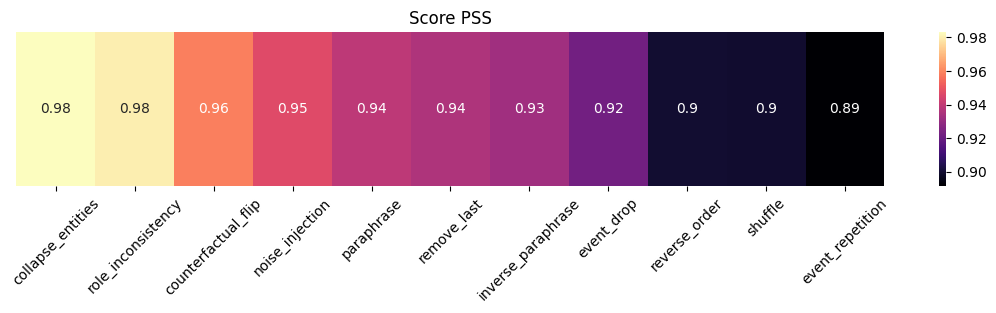

La figura muestra como varía la sensibilidad de las explicaciones frente a diferentes tipos de perturbaciones. No todas las perturbaciones afectan por igual a la estabilidad semántica de las explicaciones.

- Figura 2. PSS agrupado por categorías de perturbación

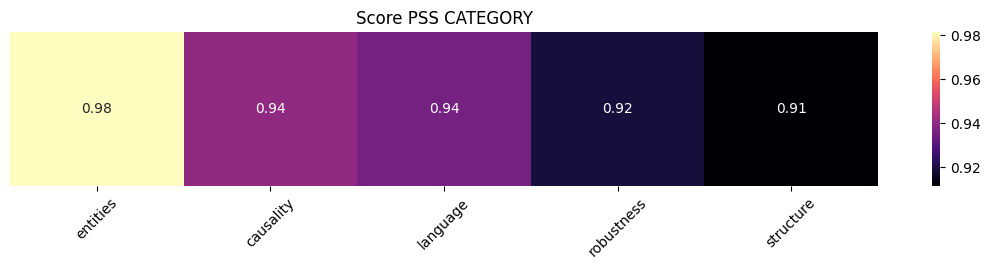

Al agrupar las perturbaciones en categorías, se observan patrones más generales. Existen diferencias entre perturbaciones estructurales, semánticas y lingüísticas.

## 5.1. Análisis cualitativo

1. El modelo no depende de los nombres de los personajes, ni se ve afectado al cambiar la identidad de estos. Esto sugiere que el razonamiento se basa en representaciones abstractas más que en entidades específicas. **Implicación XAI: buena generalización, pero puede perderse identidad narrativa**.

2. El modelo es robusto a cambios semánticos (cambios de conectores o ruido no alteran mucho la explicación). Aún así, el lenguaje afecta más que la estructura narrativa. **Implicación XAI: mayor sensibilidad a la forma lingüística que a cambios estructurales**.

3. El modelo reconstruye bastante bien la explicación incluso con información incompleta, lo que indica que el modelo no depende de todos los eventos para razonar. **Implicación XAI: falta de fidelidad a la evidencia de la historia completa**.

4. El modelo es sensible a la estructura temporal y narrativa, es decir, la explicación depende del orden de los eventos más que de los eventos. **Implicación XAI: la temporalidad y el orden narrativo son clave para generar las explicaciones.**

5. El modelo no ignora completamente la redundancia de la información. **Implicación XAI: hay un sesgo hacia redundancia textual**.

# 6. Conexión con XAI clásica

Este proyecto se relaciona con la XAI clásica en tres aspectos. \1
1. Métodos como LIME utilizan perturbaciones del input para aproximar modelos complejos. Aquí las perturbaciones se extienden al nivel narrativo completo.

2. En XAI clásica una explicación es más fiable si es estable bajo pequeñas variaciones del input. Este principio se ha traslado a este proyecto en el espacio de explicaciones generadas por LLMs.

3. Métodos como LIME o SHAP explican decisiones de modelos, pero aquí el LLM tiene dos roles: sistema generador y objeto de análisis. 

# 7. Limitaciones

Este enfoque tiene grandes limitaciones respecto a la XAI clásica. \1
1. Los resultados dependen del modelo utilizado, limitando generalización.

2. Las explicaciones pueden no ser consistentes entre ejecuciones.

3. El PSS mide similitud semántica, pero no equivalencia causal.

4. No existe ground truth explicativo: no se puede medir la fidelidad tradicional.

# 8. Consideraciones sobre el diseño del prompt y el formato de salida

Un aspecto clave del diseño del pipeline experimental es el uso de un prompt estructurado con salida en formato JSON, que restringe la generación del modelo a una representación fija de la explicación. Esta decisión no es del todo técnica, sino más bien metodológica, ya que permite controlar la salida del modelo y reducir la variabilidad en diferencias de formato o estilo de redacción.

Al tener una estructura fija con campos predefinidos (characters, events, causal_relations, narrative_structure), se garantiza que todas las explicaciones sean comparables bajo la misma representación. Esto permite centrarse en la variabilidad semántica, evitando que las diferencias de estilo del texto afecten la evaluación de estabilidad. Como consecuencia, la métrica PSS mide la estabilidad semántica de la información en cada campo de la explicación, y no la variabilidad estructural. 

No obstante, esta decisión implica una limitación: al restringir la salida del modelo, se reduce la expresividad del LLM y pueden no capturarse posibles variaciones en el estilo de la explicación. Sin embargo, se ha considerado que esta restricción es necesaria para poder comparar ejemplos y validar la estabilidad frente a perturbaciones narrativas.

# 9. Conclusiones

Este proyecto se encuentra dentro de un área emergente de la XAI aplicada a LLMs, donde no existe aún un "consenso" sobre como definir o evaluar una explicación. El proyecto explora un problema y muestra que la robustez semántica de las explicaciones no garantiza fidelidad causal.

A nivel de aprendizaje, el análisis realizado permite entender mejor las limitaciones de los LLMs como sistemas explicativos, así como la importancia de diseñar nuevas métricas para este tipo de modelos. Aunque los resultados no son comparables con los de XAI clásica, este proyecto aporta resultados sobre el comportamiento de las explicaciones generadas y su sensibilidad a diferentes perturbaciones narrativas.

# 10. Referencias

- Alvarez-Melis, D., & Jaakkola, T. (2018).  
  *On the Robustness of Interpretability Methods.*  
  https://doi.org/10.48550/arXiv.1806.08049

- Jacovi, A., & Goldberg, Y. (2020).  
  *Towards Faithfully Interpretable NLP Systems: How should we define and evaluate faithfulness?*  
  https://doi.org/10.48550/arXiv.2004.03685

- Kaggle Dataset: *1000 Stories – 100 Genres*  
Dataset utilizado para las narrativas del proyecto.  
https://www.kaggle.com/datasets/fareedkhan557/1000-stories-100-genres 

- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016).  
  *“Why Should I Trust You?” Explaining the Predictions of Any Classifier*  
  https://doi.org/10.48550/arXiv.1602.04938

- Yeh, C. K., Hsieh, C. Y., Suggala, A., Inouye, D. I., & Ravikumar, P. (2019).  
  *On the (In)fidelity and Sensitivity of Explanations.*  
  https://doi.org/10.48550/arXiv.1901.09392

- Wen, Q., Wang, J., Nan, Y., He, P., Tandon, R., & Xu, H. (2026). 
  *Embedding Perturbation may Better Reflect Intermediate-Step Uncertainty in LLM Reasoning*  
  https://doi.org/10.48550/arXiv.2602.02427


